# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163

1. Choose two vectors, two matrices, and two 3D tensors with larger sizes. Perform all calculations as instructed in the sample essay.
2. Pick a random image from the internet and perturb it with impulse noise.  
3. Refine the code to process the noisy image using a pre-designed model.  
4. Design a simple model and use it to process the noisy image.  
5. Compare the model you designed with the existing model.  

Import Libs

In [3]:
import numpy as np
import pandas as pd
import cv2
import os
import gdown
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import tensorflow as tf
import torch

from cv2 import imwrite, imread
from skimage import data, exposure, img_as_float, img_as_ubyte
from skimage import exposure
from skimage import io
from skimage.exposure import match_histograms
from scipy import ndimage
from skimage import feature
from pylab import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_local
from skimage.transform import rescale, resize
from tqdm.keras import TqdmCallback
from scipy.fftpack import dct, idct


c:\Users\lenovo\OneDrive\Document\Image-Processing-and-Analysis_MTH10317\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


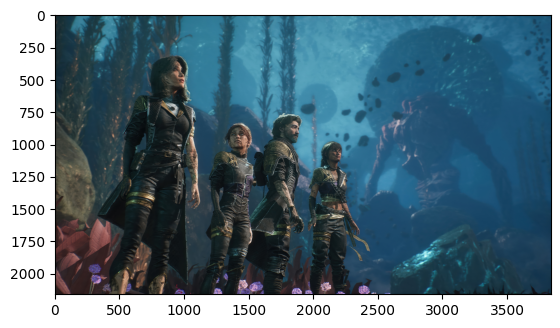

In [4]:
newImg_BGR = cv2.imread('clairobscur.jpg')  
newImg_RGB = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2RGB)


plt.imshow(newImg_RGB)

## 1. Choose two vectors, two matrices, and two 3D tensors with larger sizes. Perform all calculations as instructed in the sample essay.

In [6]:
# 1. Choose two vectors, two matrices, and two 3D tensors with larger sizes. Perform all calculations as instructed in the sample essay.


# Create a random number generator and set a fixed seed for reproducibility
gen = torch.Generator().manual_seed(23110163)

# Create two large vectors
vector1 = torch.randn(100, generator=gen)
vector2 = torch.randn(100, generator=gen)
print("Vector 1:", vector1)
print("Vector 2:", vector2)

Vector 1: tensor([-7.1893e-01, -6.7199e-01, -4.5466e-01,  8.2352e-01, -8.9368e-01,
         1.0516e+00, -5.9607e-01, -2.1128e+00,  7.4276e-03, -2.8101e-01,
         1.1314e-01,  9.4180e-01,  4.7264e-01, -6.9826e-01, -1.6953e+00,
        -5.6850e-01,  2.0510e-01, -1.5503e+00,  7.2179e-01, -1.3151e+00,
         2.7107e-02, -1.0029e+00, -3.8858e-01, -1.1298e+00, -4.7174e-01,
        -6.6529e-01, -7.3910e-01,  6.3248e-02, -9.8386e-01, -6.0070e-01,
         1.3905e+00, -1.1267e-01, -1.0403e+00, -2.6056e+00,  3.1210e-01,
         2.0637e+00,  7.3567e-01, -3.7351e-01,  1.8228e+00,  9.4106e-01,
        -9.1589e-01, -7.6056e-01,  4.7620e-02, -4.2475e-01,  4.2687e-01,
        -1.8997e-01,  2.8701e-01,  4.8435e-02, -5.8083e-01, -4.7033e-01,
         2.0501e-01,  8.1847e-01,  1.5364e+00,  1.6371e+00,  2.6201e-02,
         8.0041e-02,  7.7724e-01, -1.1827e+00,  4.6651e-01, -8.9310e-01,
         1.2192e+00, -7.4620e-01,  8.8816e-01,  7.2395e-01, -1.7935e+00,
         1.4684e-01, -2.3894e+00, -9.8735

In [7]:
print("sum:", vector1 + vector2)

sum: tensor([-1.8036, -2.1886,  0.3720,  0.9844, -1.4799,  0.3391,  0.9218, -1.8646,
        -0.1008, -1.5235,  0.6409,  0.9306,  0.1135, -1.1176, -2.1642, -1.0887,
         0.5810, -2.2288,  0.3265, -2.7732, -1.3481,  0.8125, -0.7881, -0.0662,
        -1.1367, -1.9508, -1.3972,  1.1988, -0.4137,  1.0466,  1.8312, -0.5842,
        -1.6502, -4.4293,  0.7949,  3.0488,  1.1159, -1.4614,  1.1774,  0.5766,
        -1.4883, -0.5121, -0.4576,  0.5373,  0.7884,  0.1207,  1.8911, -1.0965,
        -0.6154, -1.1175,  1.6142,  2.9176,  4.1473,  1.0415, -0.7653, -0.7422,
        -0.9067, -1.2140, -0.1592, -2.2748,  1.1891, -0.7811,  0.5210,  1.1108,
        -1.7463,  1.0285, -0.9344, -2.2057,  0.2207,  1.2827, -1.2473,  3.7503,
         2.1582,  0.4273, -0.2072,  2.6267, -1.2456, -1.5338,  0.6973, -1.7476,
        -1.4071,  0.5456,  0.5799,  0.4373, -0.9314,  2.4619, -1.7887,  0.1660,
        -0.3449,  1.2468, -0.8396,  1.6018, -0.8762, -0.8926, -1.5764, -0.0697,
         1.6574,  0.9516,  0.1773, 

In [10]:
k = 10
print("scalar multi:", k * vector1)

scalar multi: tensor([-7.1893e+00, -6.7199e+00, -4.5466e+00,  8.2352e+00, -8.9368e+00,
         1.0516e+01, -5.9607e+00, -2.1128e+01,  7.4276e-02, -2.8101e+00,
         1.1314e+00,  9.4180e+00,  4.7264e+00, -6.9826e+00, -1.6953e+01,
        -5.6850e+00,  2.0510e+00, -1.5503e+01,  7.2179e+00, -1.3151e+01,
         2.7107e-01, -1.0029e+01, -3.8858e+00, -1.1298e+01, -4.7174e+00,
        -6.6529e+00, -7.3910e+00,  6.3248e-01, -9.8386e+00, -6.0070e+00,
         1.3905e+01, -1.1267e+00, -1.0403e+01, -2.6056e+01,  3.1210e+00,
         2.0637e+01,  7.3567e+00, -3.7351e+00,  1.8228e+01,  9.4106e+00,
        -9.1589e+00, -7.6056e+00,  4.7620e-01, -4.2475e+00,  4.2687e+00,
        -1.8997e+00,  2.8701e+00,  4.8435e-01, -5.8083e+00, -4.7033e+00,
         2.0501e+00,  8.1847e+00,  1.5364e+01,  1.6371e+01,  2.6201e-01,
         8.0041e-01,  7.7724e+00, -1.1827e+01,  4.6651e+00, -8.9310e+00,
         1.2192e+01, -7.4620e+00,  8.8816e+00,  7.2395e+00, -1.7935e+01,
         1.4684e+00, -2.3894e+01, -9.

In [8]:
print("multiply:", vector1 * vector2)

multiply: tensor([ 7.7978e-01,  1.0191e+00, -3.7584e-01,  1.3245e-01,  5.2387e-01,
        -7.4924e-01, -9.0477e-01, -5.2434e-01, -8.0405e-04,  3.4915e-01,
         5.9711e-02, -1.0576e-02, -1.6975e-01,  2.9280e-01,  7.9496e-01,
         2.9573e-01,  7.7103e-02,  1.0519e+00, -2.8532e-01,  1.9175e+00,
        -3.7276e-02, -1.8207e+00,  1.5526e-01, -1.2015e+00,  3.1368e-01,
         8.5521e-01,  4.8642e-01,  7.1823e-02, -5.6096e-01, -9.8955e-01,
         6.1277e-01,  5.3127e-02,  6.3453e-01,  4.7519e+00,  1.5070e-01,
         2.0329e+00,  2.7969e-01,  4.0633e-01, -1.1765e+00, -3.4297e-01,
         5.2431e-01, -1.8894e-01, -2.4057e-02, -4.0864e-01,  1.5434e-01,
        -5.9016e-02,  4.6041e-01, -5.5453e-02,  2.0082e-02,  3.0440e-01,
         2.8890e-01,  1.7181e+00,  4.0114e+00, -9.7496e-01, -2.0737e-02,
        -6.5810e-02, -1.3089e+00,  3.7054e-02, -2.9189e-01,  1.2340e+00,
        -3.6741e-02,  2.6054e-02, -3.2614e-01,  2.8006e-01, -8.4669e-02,
         1.2946e-01, -3.4766e+00,  1.2029